# Espacio de probabilidad con Python

Este notebook presenta los fundamentos del **espacio de probabilidad** siguiendo el orden solicitado. Las definiciones están redactadas de forma propia y se apoyan en bibliografía clásica de probabilidad y estadística: **Rincón**, **Ross**, **Mood** y **Mendenhall**.

El objetivo no es hacer demostraciones largas, sino entender los conceptos principales mediante ejemplos sencillos y simulaciones en Python.

## 1. Definición de espacio de probabilidad

Un **espacio de probabilidad** es el modelo matemático que se usa para describir un experimento aleatorio. De acuerdo con la formulación usual presentada en textos como Rincón y Ross, se representa mediante una terna:

$$
(\Omega, \mathcal{F}, P)
$$

donde:

- $\Omega$ es el **espacio muestral**, es decir, el conjunto de todos los resultados posibles.
- $\mathcal{F}$ es una colección de subconjuntos de $\Omega$ llamados **eventos**.
- $P$ es una función de probabilidad que asigna a cada evento un número entre 0 y 1.

En términos prácticos, el espacio de probabilidad permite pasar de una situación aleatoria, como lanzar una moneda o un dado, a un modelo donde podemos calcular y comparar probabilidades.

> Definición basada en Rincón y Ross, quienes presentan la probabilidad como una función definida sobre eventos de un espacio muestral y sujeta a los axiomas de Kolmogorov.

In [1]:
# Importamos las bibliotecas que se usarán en los ejemplos del notebook.
# La semilla permite que las simulaciones sean reproducibles.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## 2. Espacio muestral $\Omega$

El **espacio muestral**, denotado por $\Omega$, es el conjunto de todos los resultados posibles de un experimento aleatorio. Según la presentación de Rincón, Ross y Mendenhall, antes de asignar probabilidades es necesario identificar claramente qué resultados pueden ocurrir.

Por ejemplo, si lanzamos un dado común, el espacio muestral es:

$$
\Omega = \{1,2,3,4,5,6\}
$$

Cada elemento de $\Omega$ representa un resultado elemental del experimento.

In [2]:
# Espacio muestral de un dado común
Omega_dado = {1, 2, 3, 4, 5, 6}

print("Espacio muestral del dado:", Omega_dado)
print("Número de resultados posibles:", len(Omega_dado))

Espacio muestral del dado: {1, 2, 3, 4, 5, 6}
Número de resultados posibles: 6


## 3. Eventos

Un **evento** es un subconjunto del espacio muestral. Es decir, un evento agrupa uno o varios resultados posibles del experimento. Esta idea aparece de forma estándar en Rincón, Ross, Mood y Mendenhall: si $\Omega$ contiene todos los resultados posibles, entonces un evento $A$ contiene solamente los resultados que cumplen cierta condición.

Por ejemplo, al lanzar un dado:

- El evento “obtener un número par” es $A = \{2,4,6\}$.
- El evento “obtener un número mayor que 4” es $B = \{5,6\}$.

Si ocurre un resultado que pertenece al evento, decimos que el evento ocurrió.

In [3]:
# Definimos eventos como subconjuntos del espacio muestral del dado
A = {2, 4, 6}      # Evento A: obtener un número par
B = {5, 6}         # Evento B: obtener un número mayor que 4

print("Evento A: número par =", A)
print("Evento B: número mayor que 4 =", B)
print("Intersección A ∩ B:", A & B)
print("Unión A ∪ B:", A | B)

Evento A: número par = {2, 4, 6}
Evento B: número mayor que 4 = {5, 6}
Intersección A ∩ B: {6}
Unión A ∪ B: {2, 4, 5, 6}


## 4. Axiomas de Kolmogorov

Los **axiomas de Kolmogorov** establecen las reglas básicas que debe cumplir cualquier función de probabilidad. En la forma presentada por Ross y Rincón, si $P$ es una función de probabilidad definida sobre eventos, entonces debe cumplir:

1. **No negatividad**:

$$
P(A) \geq 0
$$

para cualquier evento $A$.

2. **Normalización**:

$$
P(\Omega)=1
$$

es decir, la probabilidad de que ocurra algún resultado del espacio muestral completo es 1.

3. **Aditividad para eventos disjuntos**:

Si $A$ y $B$ no pueden ocurrir al mismo tiempo, entonces:

$$
P(A \cup B)=P(A)+P(B)
$$

Estos axiomas son importantes porque permiten construir todas las reglas usuales de la probabilidad.

In [4]:
# Función de probabilidad clásica para espacios muestrales finitos equiprobables

def P(evento, omega):
    """Calcula P(evento) cuando todos los resultados de omega son equiprobables."""
    return len(evento) / len(omega)

C = {1, 3, 5}  # Evento C: obtener número impar
D = {2, 4, 6}  # Evento D: obtener número par

print("P(C) =", P(C, Omega_dado))
print("P(D) =", P(D, Omega_dado))
print("P(Ω) =", P(Omega_dado, Omega_dado))
print("C y D son disjuntos:", C.isdisjoint(D))
print("P(C ∪ D) =", P(C | D, Omega_dado))
print("P(C) + P(D) =", P(C, Omega_dado) + P(D, Omega_dado))

P(C) = 0.5
P(D) = 0.5
P(Ω) = 1.0
C y D son disjuntos: True
P(C ∪ D) = 1.0
P(C) + P(D) = 1.0


## 5. Probabilidad condicional

La **probabilidad condicional** mide la probabilidad de que ocurra un evento $A$ sabiendo que ya ocurrió otro evento $B$. Según la definición usual en Ross, Mood y Mendenhall, si $P(B)>0$, entonces:

$$
P(A \mid B)=\frac{P(A \cap B)}{P(B)}
$$

Esta expresión cambia el espacio de referencia: ya no observamos todo $\Omega$, sino únicamente los casos en los que ocurre $B$.

Ejemplo: al lanzar un dado, calculemos la probabilidad de obtener un número par dado que el resultado fue mayor que 3.

In [5]:
# Probabilidad condicional usando conjuntos

def P_condicional(evento_A, evento_B, omega):
    """Calcula P(A|B) para un espacio muestral finito equiprobable."""
    if len(evento_B) == 0:
        raise ValueError("El evento condicionante no puede ser vacío.")
    return len(evento_A & evento_B) / len(evento_B)

A = {2, 4, 6}      # A: número par
B = {4, 5, 6}      # B: número mayor que 3

print("A =", A)
print("B =", B)
print("A ∩ B =", A & B)
print("P(A|B) =", P_condicional(A, B, Omega_dado))

A = {2, 4, 6}
B = {4, 5, 6}
A ∩ B = {4, 6}
P(A|B) = 0.6666666666666666


## 6. Independencia

Dos eventos $A$ y $B$ son **independientes** cuando la ocurrencia de uno no modifica la probabilidad del otro. En la definición algebraica usada por Ross, Mood y Mendenhall, $A$ y $B$ son independientes si:

$$
P(A \cap B)=P(A)P(B)
$$

Cuando $P(B)>0$, esta condición también puede interpretarse como:

$$
P(A \mid B)=P(A)
$$

Es decir, saber que ocurrió $B$ no cambia la probabilidad de $A$.

In [6]:
# Ejemplo con dos lanzamientos de moneda
Omega_2_monedas = {("Águila", "Águila"), ("Águila", "Sol"), ("Sol", "Águila"), ("Sol", "Sol")}

A = {resultado for resultado in Omega_2_monedas if resultado[0] == "Águila"}  # Primera moneda es águila
B = {resultado for resultado in Omega_2_monedas if resultado[1] == "Águila"}  # Segunda moneda es águila

p_A = P(A, Omega_2_monedas)
p_B = P(B, Omega_2_monedas)
p_interseccion = P(A & B, Omega_2_monedas)

print("P(A) =", p_A)
print("P(B) =", p_B)
print("P(A ∩ B) =", p_interseccion)
print("P(A)P(B) =", p_A * p_B)
print("¿Son independientes?", np.isclose(p_interseccion, p_A * p_B))

P(A) = 0.5
P(B) = 0.5
P(A ∩ B) = 0.25
P(A)P(B) = 0.25
¿Son independientes? True


## 7. Enfoque clásico

El **enfoque clásico** se aplica cuando el espacio muestral es finito y todos los resultados son igualmente probables. De acuerdo con la presentación de Mendenhall y Ross, la probabilidad de un evento se calcula como:

$$
P(A)=\frac{\text{número de casos favorables}}{\text{número de casos posibles}}
$$

Este enfoque es común en ejemplos de dados, monedas, cartas y urnas, siempre que los resultados puedan considerarse equiprobables.

In [7]:
# Enfoque clásico: probabilidad de obtener suma 7 al lanzar dos dados
Omega_dos_dados = {(i, j) for i in range(1, 7) for j in range(1, 7)}
Suma_7 = {resultado for resultado in Omega_dos_dados if sum(resultado) == 7}

print("Total de resultados posibles:", len(Omega_dos_dados))
print("Casos favorables para suma 7:", len(Suma_7))
print("P(suma 7) =", P(Suma_7, Omega_dos_dados))

Total de resultados posibles: 36
Casos favorables para suma 7: 6
P(suma 7) = 0.16666666666666666


## 8. Enfoque frecuentista

El **enfoque frecuentista** interpreta la probabilidad como el valor al que tiende la frecuencia relativa de un evento cuando el experimento se repite muchas veces bajo condiciones similares. Esta interpretación aparece en textos introductorios como Mendenhall y también se relaciona con la ley de los grandes números tratada en cursos de probabilidad como los de Ross.

Si repetimos un experimento $n$ veces y el evento $A$ ocurre $n_A$ veces, la frecuencia relativa es:

$$
\frac{n_A}{n}
$$

Al aumentar $n$, esta frecuencia relativa suele acercarse a la probabilidad teórica del evento.

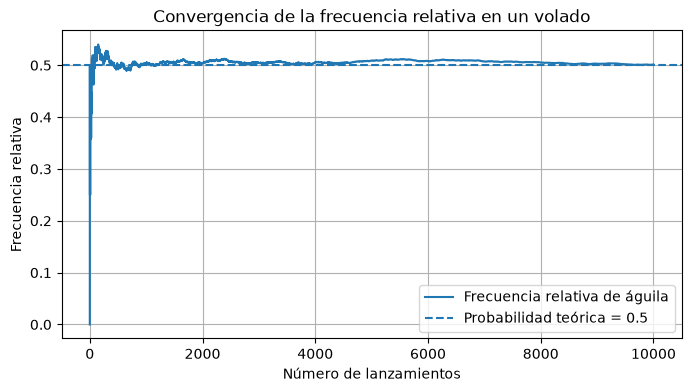

Frecuencia relativa final: 0.5015


In [8]:
# Simulación frecuentista: frecuencia relativa de águila en lanzamientos de moneda
n_lanzamientos = 10_000
lanzamientos = rng.choice(["Águila", "Sol"], size=n_lanzamientos, p=[0.5, 0.5])
frecuencia_relativa = np.cumsum(lanzamientos == "Águila") / np.arange(1, n_lanzamientos + 1)

plt.figure(figsize=(8, 4))
plt.plot(frecuencia_relativa, label="Frecuencia relativa de águila")
plt.axhline(0.5, linestyle="--", label="Probabilidad teórica = 0.5")
plt.title("Convergencia de la frecuencia relativa en un volado")
plt.xlabel("Número de lanzamientos")
plt.ylabel("Frecuencia relativa")
plt.legend()
plt.grid(True)
plt.show()

print("Frecuencia relativa final:", frecuencia_relativa[-1])

## 9. Enfoque geométrico

El **enfoque geométrico** se usa cuando los resultados posibles pueden representarse como puntos en una región geométrica y todos los puntos se consideran igualmente probables. En este caso, la probabilidad se calcula como una razón de longitudes, áreas o volúmenes.

De forma general:

$$
P(A)=\frac{\text{medida de la región favorable}}{\text{medida de la región total}}
$$

Este enfoque es útil en problemas donde el azar se representa mediante posiciones, tiempos o distancias continuas. La idea es compatible con la construcción de probabilidad sobre espacios continuos presentada en textos como Ross y Mood.

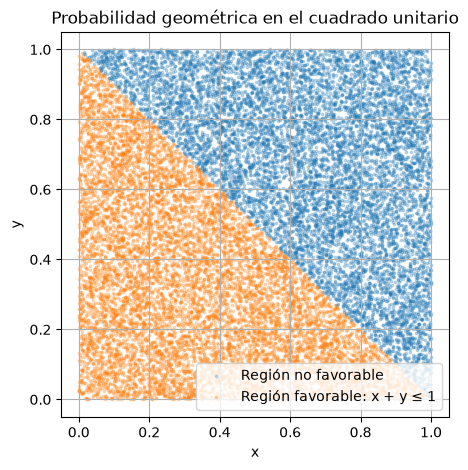

Probabilidad estimada: 0.4931
Probabilidad teórica: 0.5


In [9]:
# Ejemplo geométrico: elegir un punto al azar en el cuadrado [0,1] x [0,1]
# Queremos estimar P(x + y <= 1), cuya región favorable es un triángulo de área 1/2.

n_puntos = 20_000
puntos = rng.random((n_puntos, 2))
x = puntos[:, 0]
y = puntos[:, 1]
favorable = x + y <= 1
probabilidad_estimada = favorable.mean()

plt.figure(figsize=(5, 5))
plt.scatter(x[~favorable], y[~favorable], s=3, alpha=0.25, label="Región no favorable")
plt.scatter(x[favorable], y[favorable], s=3, alpha=0.25, label="Región favorable: x + y ≤ 1")
plt.title("Probabilidad geométrica en el cuadrado unitario")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

print("Probabilidad estimada:", probabilidad_estimada)
print("Probabilidad teórica:", 0.5)

## 10. Problema del encuentro

El **problema del encuentro** es un ejemplo clásico de probabilidad geométrica. Supongamos que dos personas acuerdan encontrarse entre las 12:00 y la 1:00. Cada una llega al azar, de manera independiente, dentro de ese intervalo. Si cada persona espera 15 minutos, queremos calcular la probabilidad de que se encuentren.

Sea:

- $X$: tiempo de llegada de la primera persona.
- $Y$: tiempo de llegada de la segunda persona.

Ambos tiempos se pueden representar como puntos en el intervalo $[0,60]$. Las personas se encuentran si:

$$
|X-Y| \leq 15
$$

Geométricamente, el espacio total es un cuadrado de lado 60 y la región favorable es la franja alrededor de la diagonal donde la diferencia entre llegadas no supera 15 minutos.

La probabilidad teórica es:

$$
P(|X-Y| \leq 15)=1-\left(\frac{45}{60}\right)^2=\frac{7}{16}=0.4375
$$

Este problema conecta directamente con el enfoque geométrico descrito en textos de probabilidad como Ross y Rincón.

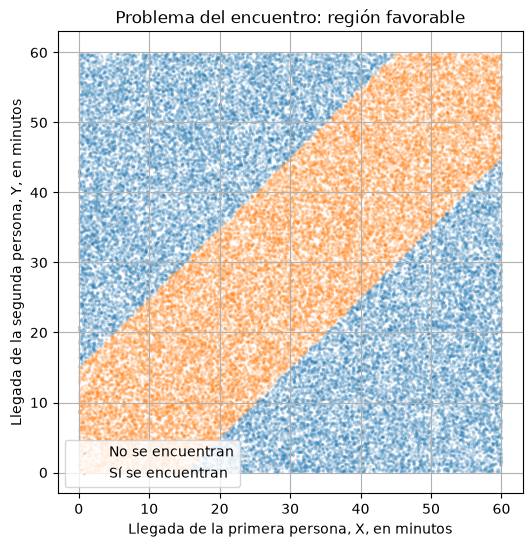

Probabilidad simulada: 0.4405
Probabilidad teórica: 0.4375


In [10]:
# Simulación del problema del encuentro
n_simulaciones = 50_000
x_llegada = rng.uniform(0, 60, n_simulaciones)
y_llegada = rng.uniform(0, 60, n_simulaciones)
se_encuentran = np.abs(x_llegada - y_llegada) <= 15
probabilidad_simulada = se_encuentran.mean()
probabilidad_teorica = 7 / 16

plt.figure(figsize=(6, 6))
plt.scatter(x_llegada[~se_encuentran], y_llegada[~se_encuentran], s=2, alpha=0.15, label="No se encuentran")
plt.scatter(x_llegada[se_encuentran], y_llegada[se_encuentran], s=2, alpha=0.15, label="Sí se encuentran")
plt.title("Problema del encuentro: región favorable")
plt.xlabel("Llegada de la primera persona, X, en minutos")
plt.ylabel("Llegada de la segunda persona, Y, en minutos")
plt.legend()
plt.grid(True)
plt.show()

print("Probabilidad simulada:", probabilidad_simulada)
print("Probabilidad teórica:", probabilidad_teorica)

## 11. Ejemplo del volado

El **volado** es uno de los ejemplos más simples de experimento aleatorio. Si la moneda es justa, el espacio muestral es:

$$
\Omega = \{\text{Águila}, \text{Sol}\}
$$

Bajo el enfoque clásico, ambos resultados se consideran igualmente probables, por lo que:

$$
P(\text{Águila})=\frac{1}{2}, \quad P(\text{Sol})=\frac{1}{2}
$$

Este ejemplo ayuda a distinguir entre el cálculo teórico de probabilidad y la aproximación por simulación frecuentista.

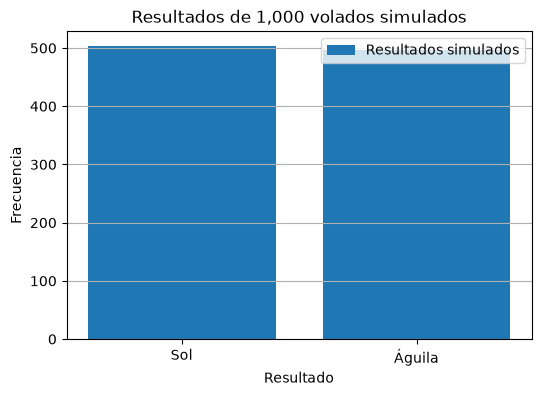

P(Águila) clásica: 0.5
P(Águila) simulada: 0.496


In [11]:
# Ejemplo del volado con simulación
Omega_volado = {"Águila", "Sol"}
A_aguila = {"Águila"}

n = 1_000
volados = rng.choice(["Águila", "Sol"], size=n)
probabilidad_clasica = P(A_aguila, Omega_volado)
probabilidad_simulada = np.mean(volados == "Águila")

conteo = pd.Series(volados).value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(conteo.index, conteo.values, label="Resultados simulados")
plt.title("Resultados de 1,000 volados simulados")
plt.xlabel("Resultado")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(axis="y")
plt.show()

print("P(Águila) clásica:", probabilidad_clasica)
print("P(Águila) simulada:", probabilidad_simulada)

## 12. Ejemplo adicional propio: inspección de archivos recibidos

Un ejemplo propio relacionado con datos consiste en revisar archivos recibidos en un proceso. Supongamos que durante una ejecución se reciben archivos con dos posibles estados:

- **Válido**: el archivo cumple la nomenclatura y puede procesarse.
- **Inválido**: el archivo no cumple la regla y debe rechazarse.

Si elegimos un archivo al azar de la ejecución, el espacio muestral está formado por todos los archivos recibidos. El evento de interés puede ser:

$$
A = \{\text{archivos válidos}\}
$$

Este ejemplo muestra que la probabilidad no solamente aplica a monedas o dados; también puede modelar situaciones de validación en procesos de datos.

In [12]:
# Ejemplo propio: probabilidad de seleccionar un archivo válido de una ejecución
archivos = pd.DataFrame({
    "archivo": [
        "report_001.txt", "report_002.txt", "error_003.txt",
        "report_004.txt", "report_final.csv", "report_005.txt",
        "temporal.txt", "report_006.txt"
    ]
})

# Un archivo es válido si empieza con 'report_' y termina con '.txt'
archivos["es_valido"] = archivos["archivo"].str.startswith("report_") & archivos["archivo"].str.endswith(".txt")

Omega_archivos = set(archivos["archivo"])
Evento_valido = set(archivos.loc[archivos["es_valido"], "archivo"])
probabilidad_archivo_valido = len(Evento_valido) / len(Omega_archivos)

print(archivos)
print("\nNúmero total de archivos:", len(Omega_archivos))
print("Número de archivos válidos:", len(Evento_valido))
print("P(archivo válido) =", probabilidad_archivo_valido)

            archivo  es_valido
0    report_001.txt       True
1    report_002.txt       True
2     error_003.txt      False
3    report_004.txt       True
4  report_final.csv      False
5    report_005.txt       True
6      temporal.txt      False
7    report_006.txt       True

Número total de archivos: 8
Número de archivos válidos: 5
P(archivo válido) = 0.625


## Conclusión

Un espacio de probabilidad permite modelar formalmente un experimento aleatorio mediante tres componentes: el espacio muestral $\Omega$, los eventos y la función de probabilidad $P$. A partir de esta estructura se pueden estudiar conceptos fundamentales como los axiomas de Kolmogorov, la probabilidad condicional y la independencia.

También se revisaron tres enfoques importantes: el clásico, que se basa en casos igualmente probables; el frecuentista, que interpreta la probabilidad mediante frecuencias relativas en repeticiones del experimento; y el geométrico, que calcula probabilidades como razones de medidas en regiones continuas.

Los ejemplos del dado, el volado, el problema del encuentro y la validación de archivos muestran que la probabilidad puede aplicarse tanto a problemas tradicionales como a situaciones cercanas al análisis de datos. Las simulaciones en Python ayudan a comprobar de forma empírica los resultados teóricos y fortalecen la comprensión conceptual.

## Bibliografía

- Rincón, L. *Introducción a la probabilidad*. Material de probabilidad, UNAM.
- Ross, S. M. *A First Course in Probability*. Pearson.
- Mood, A. M., Graybill, F. A., & Boes, D. C. *Introduction to the Theory of Statistics*. McGraw-Hill.
- Mendenhall, W., Beaver, R. J., & Beaver, B. M. *Introduction to Probability and Statistics*. Cengage Learning.

Las definiciones incluidas en el notebook fueron redactadas de forma propia con base en estas fuentes, especialmente en la presentación estándar de espacio muestral, eventos, axiomas de probabilidad, probabilidad condicional, independencia y enfoques de interpretación de la probabilidad.